# M6 - Final Exam 2 (Assignment) - Advanced Machine Learning

## Linear Regression and XGBRegressor Methods

# Business Context:

The data has 506 cases where each case is a location in Boston. The `MEDV` variable represents the median housing price, while the other variables describe factors such as crime, pollution, taxation, accessibility, and housing characteristics.

The objective is to build and compare Linear Regression and XGBoost Regression models to predict housing prices and identify the most relevant variables affecting price variation.

## Questions:

* Import the dataset and perform exploratory checks, convert data types and create dummy variables wherever required.
* Split the dataset into training and testing sets using an appropriate ratio.
* Build a Linear Regression model to predict housing prices and evaluate its performance (based on RMSE).
* Build an XGBoost Regressor model for housing price prediction using suitable hyperparameters (based on RMSE).
    * `learning_rate=0.1`
    * `n_estimators=300`
    * `max_depth=4`
    * `random_state=42`
* Compare the performance of both models using RMSE (Root Mean Squared Error).
* Interpret the results of the best-performing model.


In [80]:
import warnings
warnings.filterwarnings("ignore")

In [81]:
import pandas as pd

df = pd.read_csv("Housing Prices.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [82]:
df.dtypes

CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
LSTAT      float64
MEDV       float64
dtype: object

In [83]:
df.describe().round(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,37.97,50.00


In [84]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
LSTAT      0
MEDV       0
dtype: int64

## Exploratory Summary

The dataset is fully numeric and contains no missing values. `CHAS` is a binary indicator, so it will be treated as a categorical variable and converted into a dummy variable for modeling. `MEDV` is the target variable to be predicted.


In [85]:
df_model = df.copy()
df_model["CHAS"] = df_model["CHAS"].astype("category")

df_model.dtypes

CRIM        float64
ZN          float64
INDUS       float64
CHAS       category
NOX         float64
RM          float64
AGE         float64
DIS         float64
RAD           int64
TAX           int64
PTRATIO     float64
LSTAT       float64
MEDV        float64
dtype: object

In [86]:
X = pd.get_dummies(df_model.drop(columns="MEDV"), drop_first=True)
y = df_model["MEDV"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
X.head()

Feature matrix shape: (506, 12)
Target vector shape: (506,)


,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,CHAS_1
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,False
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,False
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,False
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,False
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,False


Only one dummy column is created (`CHAS_1`), since `CHAS` is the only categorical field that requires encoding.


In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (404, 12)
X_test shape: (102, 12)
y_train shape: (404,)
y_test shape: (102,)


An 80/20 split is appropriate here, giving enough observations for training while keeping a separate test sample for unbiased model evaluation.


In [88]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)
linear_rmse = mean_squared_error(y_test, linear_predictions) ** 0.5

print(f"Linear Regression RMSE: {linear_rmse:.4f}")

Linear Regression RMSE: 4.7726


In [89]:
linear_coefficients = (
    pd.Series(linear_model.coef_, index=X_train.columns)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

linear_coefficients.head(10)

NOX       -18.183246
RM          4.240098
CHAS_1      3.049477
DIS        -1.465507
PTRATIO    -0.894845
LSTAT      -0.537770
RAD         0.239990
CRIM       -0.127196
ZN          0.030795
INDUS       0.025248
dtype: float64

The linear model provides a useful baseline and also offers coefficient-based interpretability, but its predictive power is limited because housing prices may contain non-linear relationships and interactions.


In [90]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    learning_rate=0.1,
    n_estimators=300,
    max_depth=4,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)
xgb_rmse = mean_squared_error(y_test, xgb_predictions) ** 0.5

print(f"XGBoost RMSE: {xgb_rmse:.4f}")

XGBoost RMSE: 2.6626


In [91]:
rmse_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost Regressor"],
    "RMSE": [linear_rmse, xgb_rmse]
}).sort_values(by="RMSE")

rmse_comparison

,Model,RMSE
1,XGBoost Regressor,2.66256
0,Linear Regression,4.77260


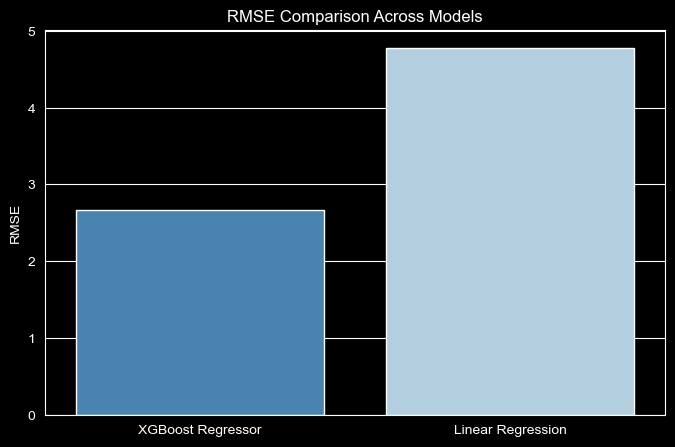

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(data=rmse_comparison, x="Model", y="RMSE", palette="Blues_r")
plt.title("RMSE Comparison Across Models")
plt.ylabel("RMSE")
plt.xlabel("")
plt.show()

The XGBoost model achieves the lower RMSE, so it is the best-performing model on the test set.


In [93]:
xgb_feature_importance = (
    pd.Series(xgb_model.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)

xgb_feature_importance.head(10)

RM         0.365230
LSTAT      0.325191
PTRATIO    0.077659
DIS        0.071814
TAX        0.032037
CRIM       0.029873
NOX        0.029825
CHAS_1     0.026241
RAD        0.017175
AGE        0.013846
dtype: float32

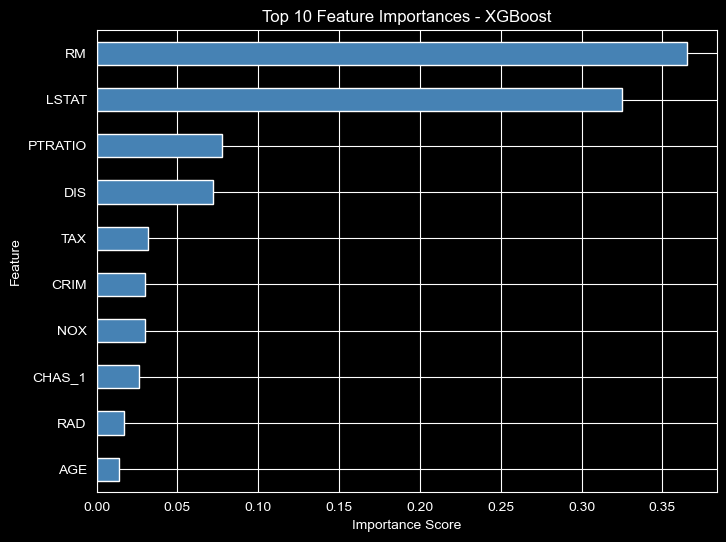

In [94]:
plt.figure(figsize=(8, 6))
xgb_feature_importance.head(10).sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 10 Feature Importances - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

## Interpretation of the Best Model

The XGBoost Regressor performs substantially better than Linear Regression, with a test RMSE of approximately `2.6626` versus `4.7726` for the linear model. This indicates that XGBoost captures the structure of housing prices more effectively.

The most important variables in the XGBoost model are `RM`, `LSTAT`, `PTRATIO`, and `DIS`. This suggests that the number of rooms, lower-status population percentage, pupil-teacher ratio, and distance to employment centers are among the strongest drivers of Boston housing prices in this dataset.

From a business perspective, the result implies that housing prices are not determined only by simple linear effects. A flexible model such as XGBoost is better suited because it can learn non-linear patterns and interactions between socioeconomic, geographic, and structural housing variables.
